<a href="https://colab.research.google.com/github/SalmaAnindhia/PCVK26_25_Salma/blob/main/P3_Tugas_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Salma Nur Anindhia'
NIM  = '244107020186'

N    = int(NIM[-3:])
PARAM = {
    'b'   : (N % 61) + 20,
    'a'   : round(1.0 + (N % 9) / 10, 1),
    'c'   : (N % 20) + 30,
    'gamma': round(0.4 + (N % 6) * 0.25, 2),
    'bit' : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA  :', NAMA)
print('NIM   :', NIM, '| N =', N)
for k, v in PARAM.items():
    print("%-6s :" % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA  : Salma Nur Anindhia
NIM   : 244107020186 | N = 186
b      : 23
a      : 1.6
c      : 36
gamma  : 0.4
bit    : 2
WAKTU  : 2026-09-17 18:35:59 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 85a2a269741d2c5b


In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab.patches import cv2_imshow

Mengubah tingkat kecerahan citra
------------------------------
Masukkan nilai kecerahan: 3


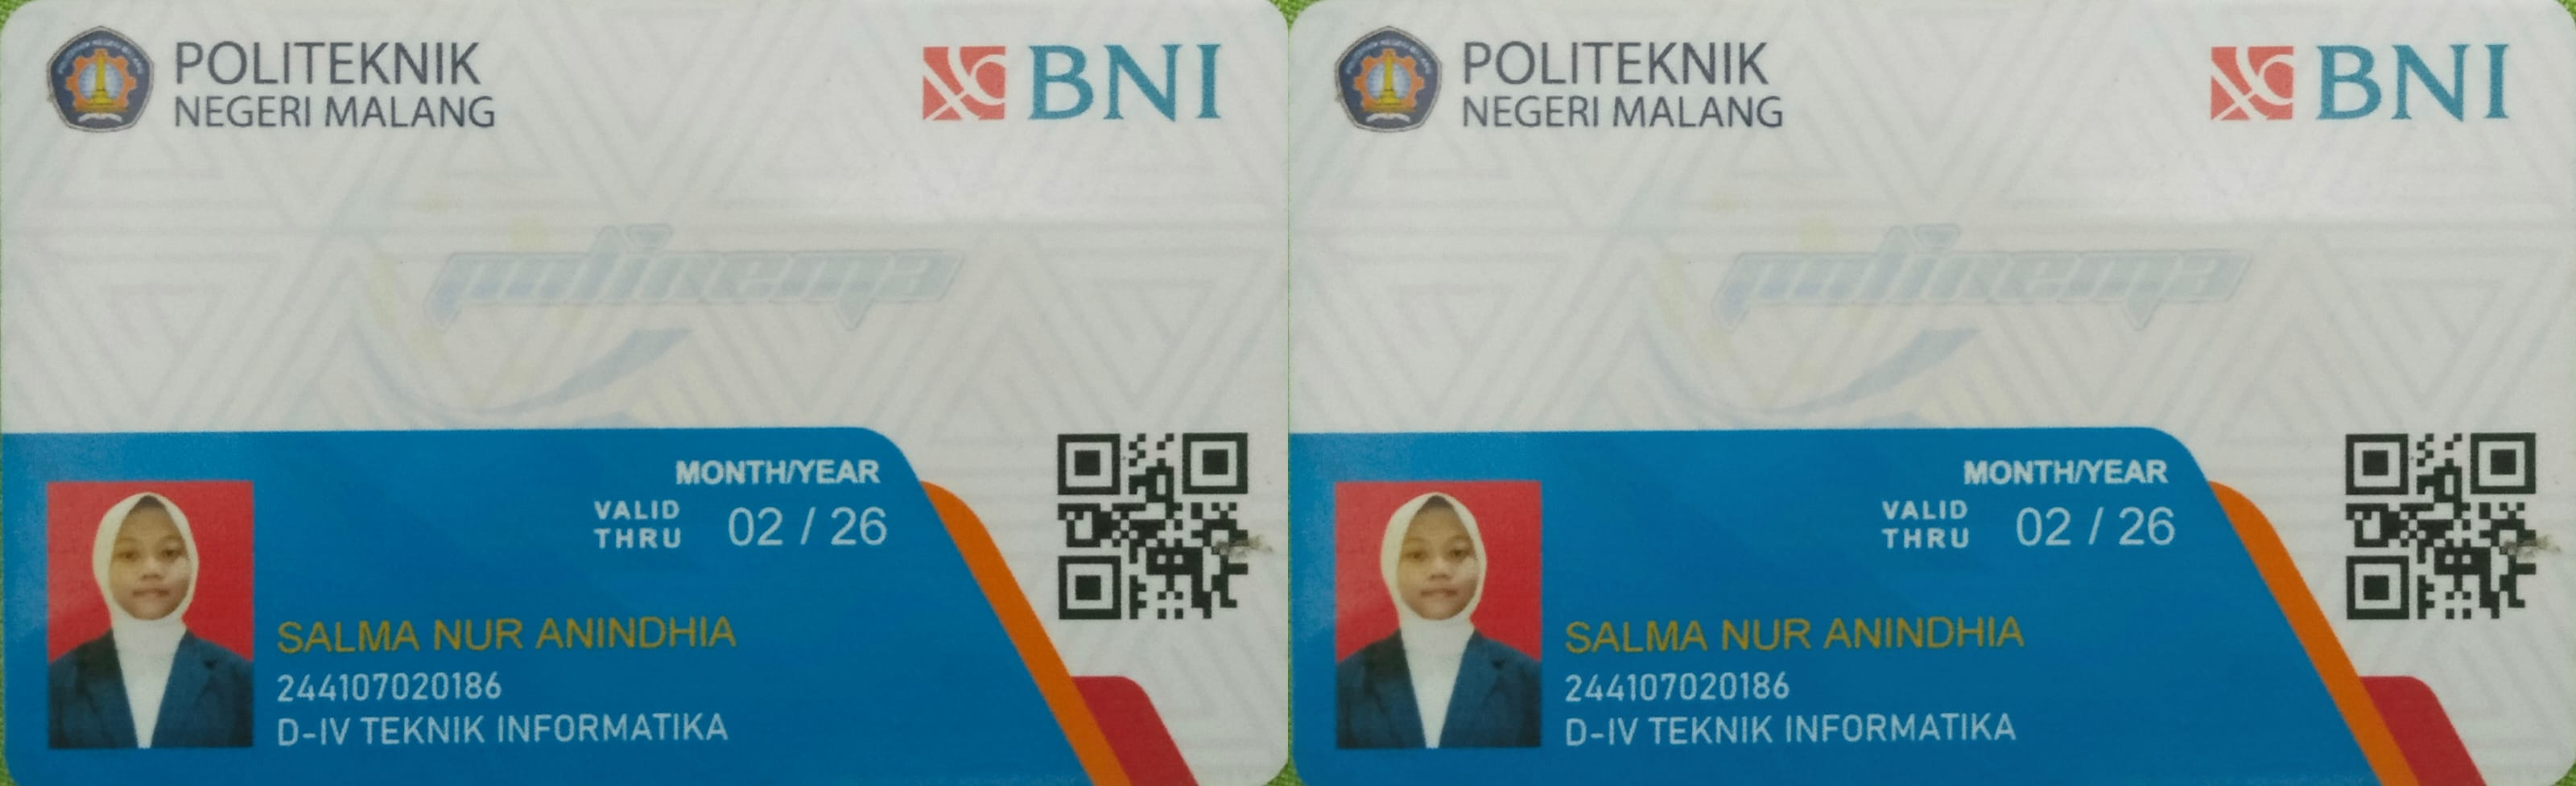

In [5]:
print('Mengubah tingkat kecerahan citra')
print('------------------------------')

try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/MATKUL BU HANI/KTM/contohKTM.jpeg')

brightness_image = np.zeros(original.shape, dtype=np.uint8)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

final_frame = cv.hconcat((original, brightness_image))

cv2_imshow(final_frame)

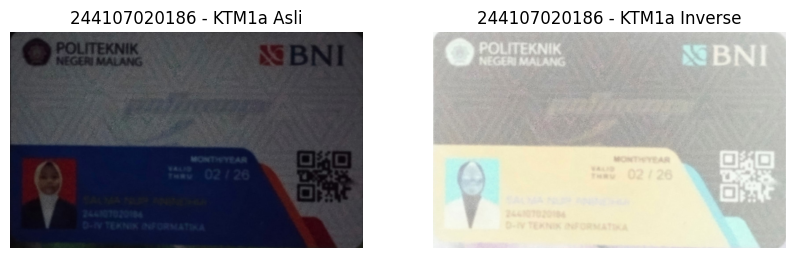

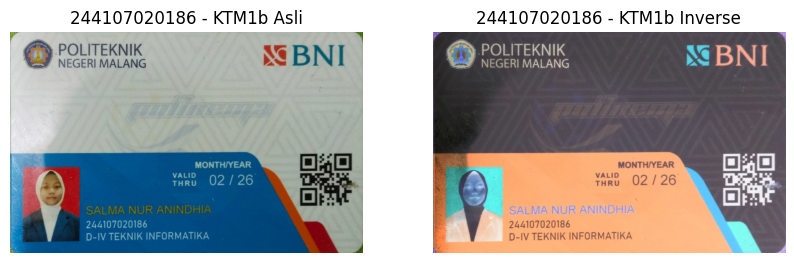

In [14]:
#tgs 1
img1 = cv.imread('/content/drive/MyDrive/MATKUL BU HANI/KTM/KTM1a.jpeg')
img2 = cv.imread('/content/drive/MyDrive/MATKUL BU HANI/KTM/KTM1b.jpeg')

inverse1 = 255 - img1
inverse2 = 255 - img2

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img1, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1a Asli')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(inverse1, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1a Inverse')
plt.axis('off')
plt.show()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img2, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1b Asli')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(inverse2, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1b Inverse')
plt.axis('off')
plt.show()

In [7]:
def imshow_bgr(img):
    if len(img.shape) == 3:
        return cv.cvtColor(img, cv.COLOR_BGR2RGB)
    return img
def truncate(arr):
    return np.clip(arr, 0, 255).astype(np.uint8)

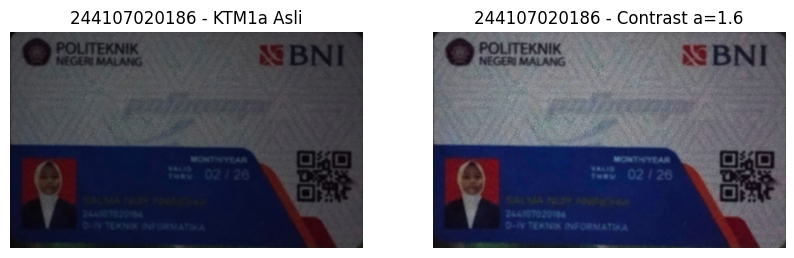

In [15]:
#tgs 2
def contrast_ab(img, a, b):
    img = img.astype(np.float64)
    hasil = a * img + b
    return truncate(hasil)

ktm1a = cv.imread('/content/drive/MyDrive/MATKUL BU HANI/KTM/KTM1a.jpeg')
hasil_kontras = contrast_ab(ktm1a, PARAM['a'], 0)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(imshow_bgr(ktm1a)); ax[0].set_title(NIM + ' - KTM1a Asli'); ax[0].axis('off')
ax[1].imshow(imshow_bgr(hasil_kontras)); ax[1].set_title(NIM + ' - Contrast a=' + str(PARAM['a'])); ax[1].axis('off')
plt.show()

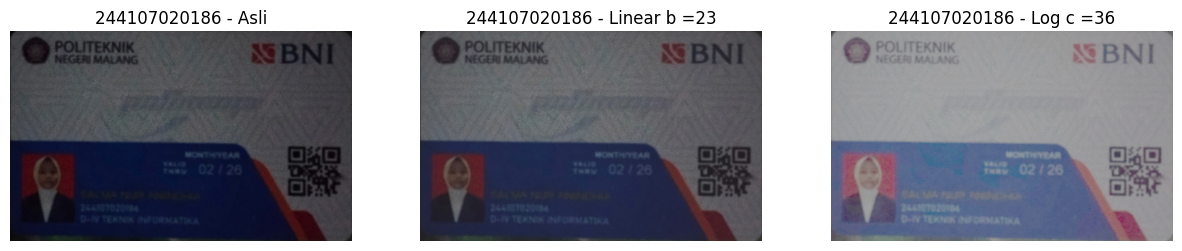

In [17]:
#tgs 3
def log_brightness(img, c):
    img = img.astype(np.float64)
    hasil = c * np.log1p(img)
    return truncate(hasil)

def linear_brightness(img, b):
    img = img.astype(np.int16)
    hasil = img + b
    return truncate(hasil)

ktm1a = cv.imread('/content/drive/MyDrive/MATKUL BU HANI/KTM/KTM1a.jpeg')
hasil_log = log_brightness(ktm1a, PARAM['c'])
hasil_lin = linear_brightness(ktm1a, PARAM['b'])

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(imshow_bgr(ktm1a)); ax[0].set_title(NIM + ' - Asli'); ax[0].axis('off')
ax[1].imshow(imshow_bgr(hasil_lin)); ax[1].set_title(NIM + ' - Linear b =' + str(PARAM['b'])); ax[1].axis('off')
ax[2].imshow(imshow_bgr(hasil_log)); ax[2].set_title(NIM + ' - Log c =' + str(PARAM['c'])); ax[2].axis('off')
plt.show()

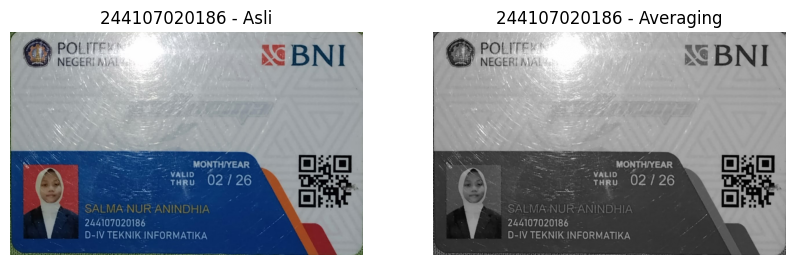

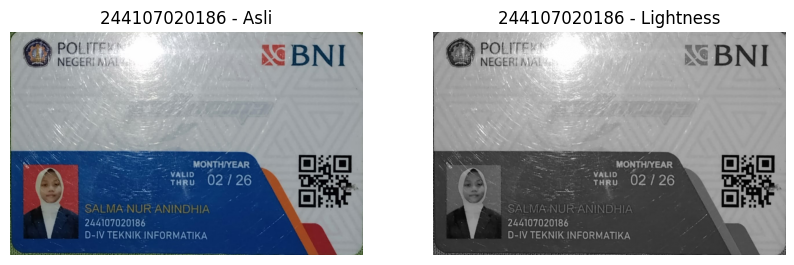

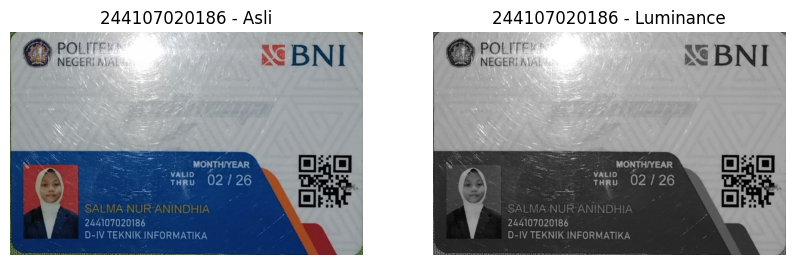

In [21]:
#tgs 4
def grayscale_average(img):
    img = img.astype(np.float64)
    b, g, r = cv.split(img)
    return truncate((r + g + b) / 3)

def grayscale_lightness(img):
    img = img.astype(np.float64)
    b, g, r = cv.split(img)
    hasil = (np.maximum(np.maximum(r, g), b) + np.minimum(np.minimum(r, g), b)) / 2
    return truncate(hasil)

def grayscale_luminance(img):
    img = img.astype(np.float64)
    b, g, r = cv.split(img)
    hasil = 0.21*r + 0.72*g + 0.07*b
    return truncate(hasil)

ktm1c = cv.imread('/content/drive/MyDrive/MATKUL BU HANI/KTM/KTM1c.jpeg')
gray_avg   = grayscale_average(ktm1c)
gray_light = grayscale_lightness(ktm1c)
gray_lum   = grayscale_luminance(ktm1c)

for nama, img_g in [('Averaging', gray_avg), ('Lightness', gray_light), ('Luminance', gray_lum)]:
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(imshow_bgr(ktm1c)); ax[0].set_title(NIM + ' - Asli'); ax[0].axis('off')
    ax[1].imshow(img_g, cmap='gray'); ax[1].set_title(NIM + ' - ' + nama); ax[1].axis('off')
    plt.show()

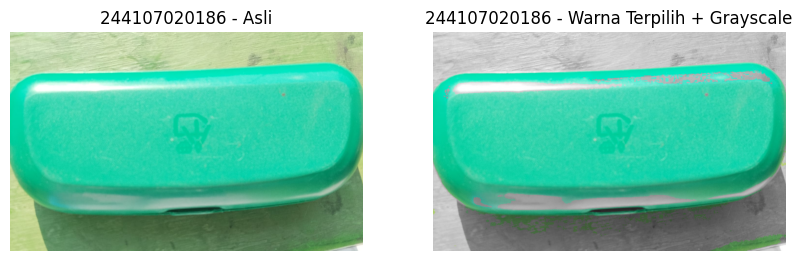

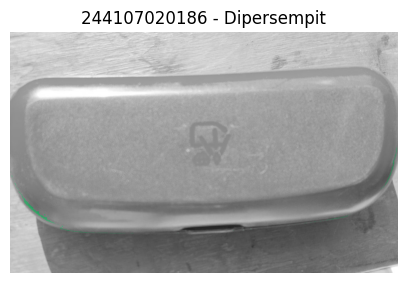

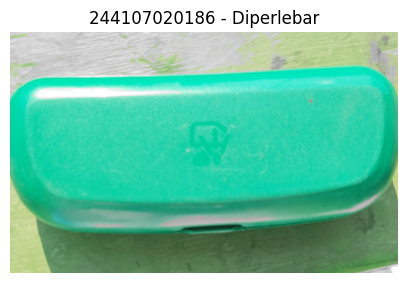

In [53]:
obj1 = cv.imread('/content/drive/MyDrive/MATKUL BU HANI/KTM//OBJ1.jpeg')
hsv = cv.cvtColor(obj1, cv.COLOR_BGR2HSV)

lower = np.array([35, 100, 80])
upper = np.array([85, 255, 255])
mask = cv.inRange(hsv, lower, upper)
mask_inv = cv.bitwise_not(mask)

gray_bg = cv.cvtColor(cv.cvtColor(obj1, cv.COLOR_BGR2GRAY), cv.COLOR_GRAY2BGR)
warna_asli = cv.bitwise_and(obj1, obj1, mask=mask)
latar_gray = cv.bitwise_and(gray_bg, gray_bg, mask=mask_inv)
hasil_akhir = cv.add(warna_asli, latar_gray)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(imshow_bgr(obj1)); ax[0].set_title(NIM + ' - Asli'); ax[0].axis('off')
ax[1].imshow(imshow_bgr(hasil_akhir)); ax[1].set_title(NIM + ' - Warna Terpilih + Grayscale'); ax[1].axis('off')
plt.show()

lower_sempit, upper_sempit = np.array([45, 150, 120]), np.array([75, 255, 255])
lower_lebar,  upper_lebar  = np.array([25, 60, 40]),   np.array([95, 255, 255])

for label, lo, up in [('Dipersempit', lower_sempit, upper_sempit), ('Diperlebar', lower_lebar, upper_lebar)]:
    m = cv.inRange(hsv, lo, up)
    warna = cv.bitwise_and(obj1, obj1, mask=m)
    latar = cv.bitwise_and(gray_bg, gray_bg, mask=cv.bitwise_not(m))
    hasil = cv.add(warna, latar)
    plt.figure(figsize=(5,5)); plt.imshow(imshow_bgr(hasil)); plt.title(NIM + ' - ' + label); plt.axis('off'); plt.show()

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma : 5


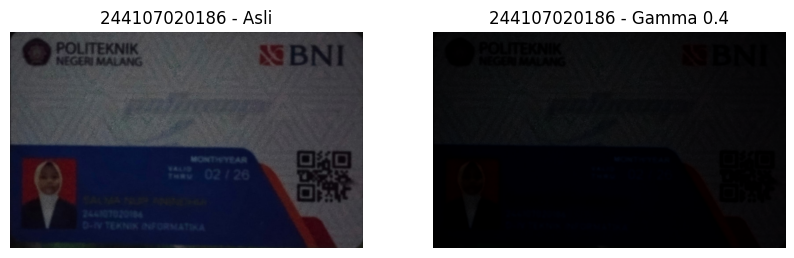

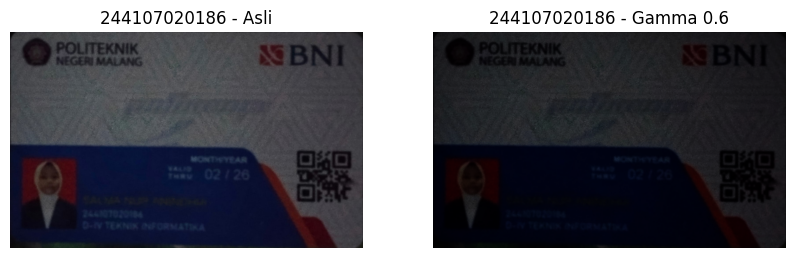

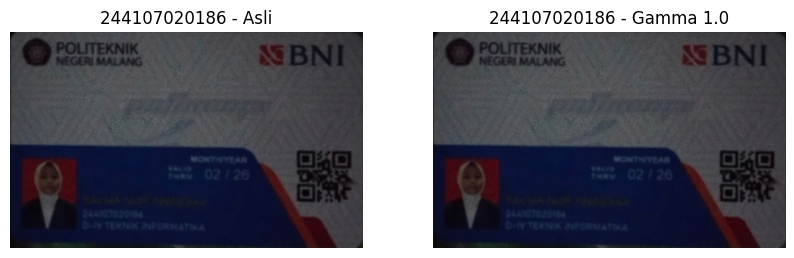

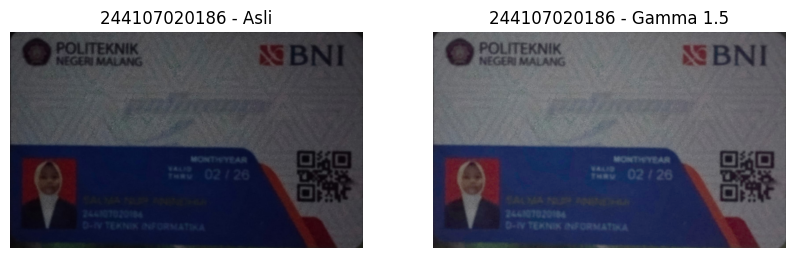

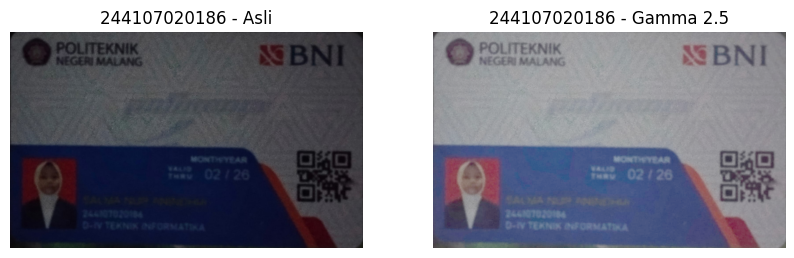

In [44]:
print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma_input = float(input('Masukkan nilai Gamma : ') or PARAM['gamma'])
except ValueError:
    print('Error, not a number'); gamma_input = PARAM['gamma']

def gamma_correction(img, gamma):
    img = img.astype(np.float64)
    return truncate(255 * (img/255) ** (1/gamma))

ktm1a = cv.imread('/content/drive/MyDrive/MATKUL BU HANI/KTM/KTM1a.jpeg')
daftar_gamma = [PARAM['gamma'], 0.6, 1.0, 1.5, 2.5]
for g in daftar_gamma:
    hasil = gamma_correction(ktm1a, g)
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(imshow_bgr(ktm1a)); ax[0].set_title(NIM + ' - Asli'); ax[0].axis('off')
    ax[1].imshow(imshow_bgr(hasil)); ax[1].set_title(NIM + ' - Gamma ' + str(g)); ax[1].axis('off')
    plt.show()

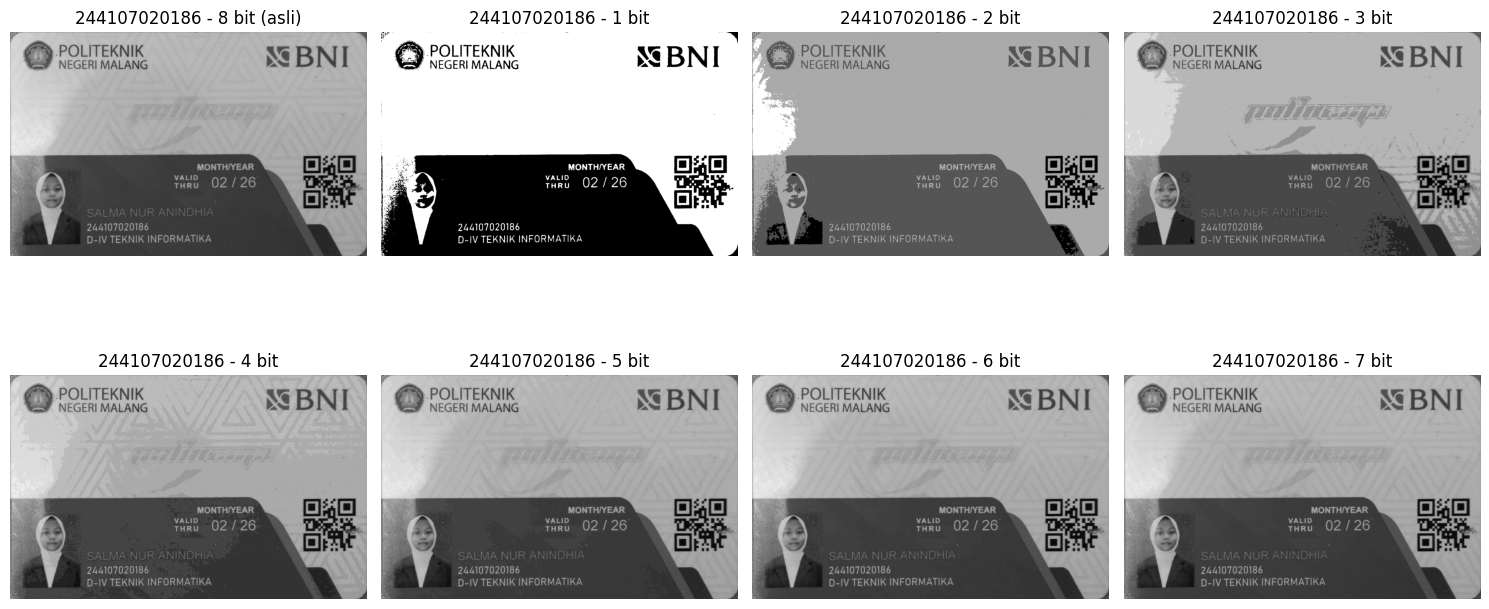

In [12]:
def simulasi_bit_depth(img_gray, bit_depth):
    level = 255 / (2**bit_depth - 1)
    hasil = np.round(img_gray / level) * level
    return hasil.astype(np.uint8)


ktm1b_gray = cv.imread('/content/drive/MyDrive/MATKUL BU HANI/KTM/KTM1b.jpeg', cv.IMREAD_GRAYSCALE)
plt.figure(figsize=(15, 8))
for i in range(1, 8):
    hasil = simulasi_bit_depth(ktm1b_gray, i)

    plt.subplot(2, 4, i + 1)
    plt.imshow(hasil, cmap='gray')
    plt.title(NIM + ' - ' + str(i) + ' bit')
    plt.axis('off')

plt.subplot(2, 4, 1)
plt.imshow(ktm1b_gray, cmap='gray')
plt.title(NIM + ' - 8 bit (asli)')
plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
import glob

Jumlah citra noise terbaca: 100


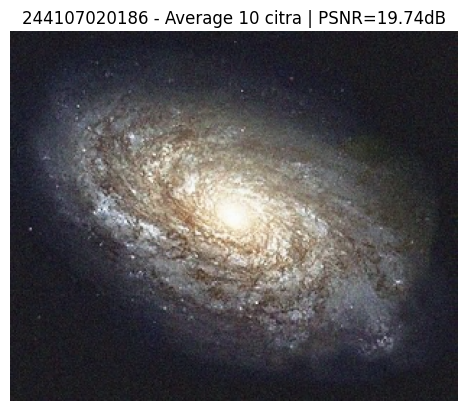

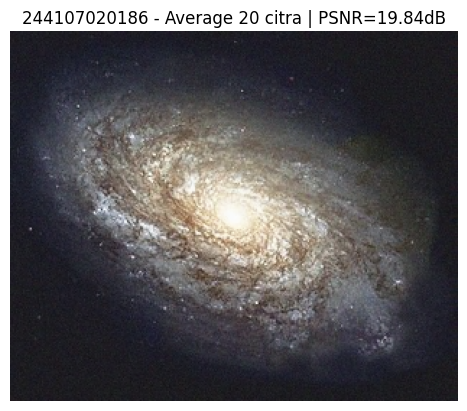

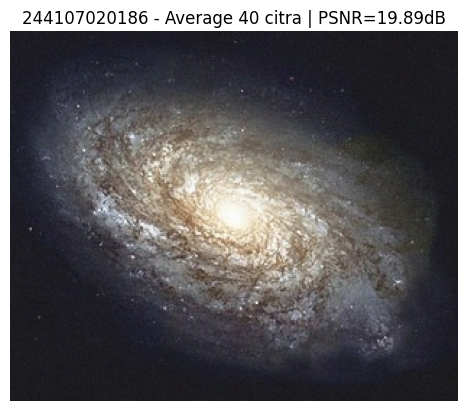

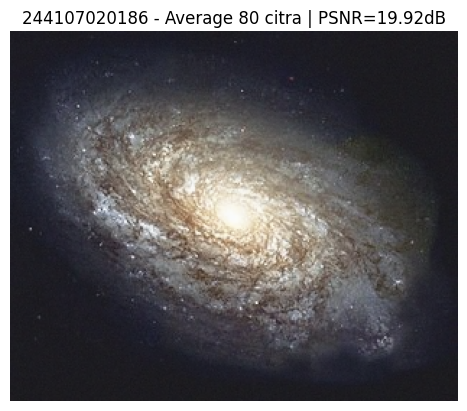

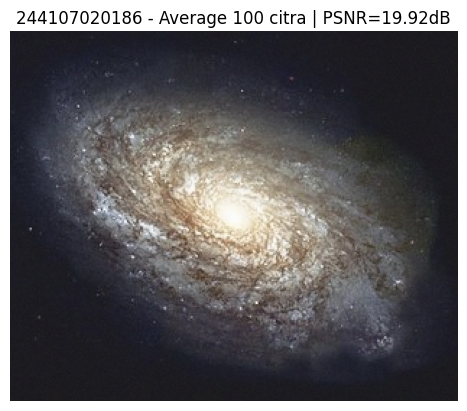

   Jumlah Citra  PSNR (dB)
0            10      19.74
1            20      19.84
2            40      19.89
3            80      19.92
4           100      19.92


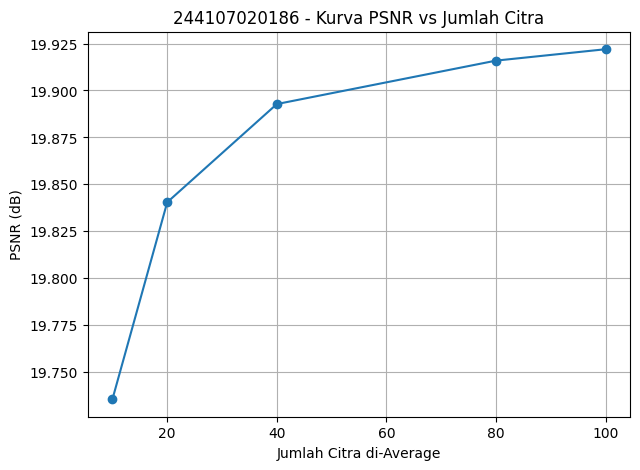

In [11]:
def PSNR(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))

galaxy_asli = cv.imread('/content/drive/MyDrive/MATKUL BU HANI/galaxy.jpg')

cv_img = []
for f in sorted(glob.glob('/content/drive/MyDrive/MATKUL BU HANI/noises/*.jpg')):
    cv_img.append(cv.imread(f))
print('Jumlah citra noise terbaca:', len(cv_img))

def average_denoise(daftar_citra, n):
    tumpukan = np.stack([c.astype(np.float64) for c in daftar_citra[:n]], axis=0)
    return truncate(np.mean(tumpukan, axis=0))

jumlah_uji = [10, 20, 40, 80, 100]
hasil_psnr = []
for n in jumlah_uji:
    hasil = average_denoise(cv_img, n)
    psnr = PSNR(galaxy_asli, hasil)
    hasil_psnr.append(psnr)
    plt.imshow(imshow_bgr(hasil)); plt.title(NIM + ' - Average ' + str(n) + ' citra | PSNR=' + str(round(psnr,2)) + 'dB'); plt.axis('off'); plt.show()

tabel8 = pd.DataFrame({'Jumlah Citra': jumlah_uji, 'PSNR (dB)': [round(p,2) for p in hasil_psnr]})
print(tabel8)

plt.figure(figsize=(7,5))
plt.plot(jumlah_uji, hasil_psnr, marker='o')
plt.xlabel('Jumlah Citra di-Average'); plt.ylabel('PSNR (dB)'); plt.title(NIM + ' - Kurva PSNR vs Jumlah Citra')
plt.grid(True); plt.show()

1. peningkatan citra tidak selalu memberikan peningkatan PSNR yang signifikan, kalau diliat di awal yakni di citra 10-20 itu peningkatan PSNR nya naik sekali namun saat di 40-100 itu kenaikan PSNR tidak terlalu

2. Di citra 40, averaging ampuh untuk mengurangi noise, tapi semakin banyak citra nya dia akan menurun, jadi sebaiknya cukup 40 citra aja

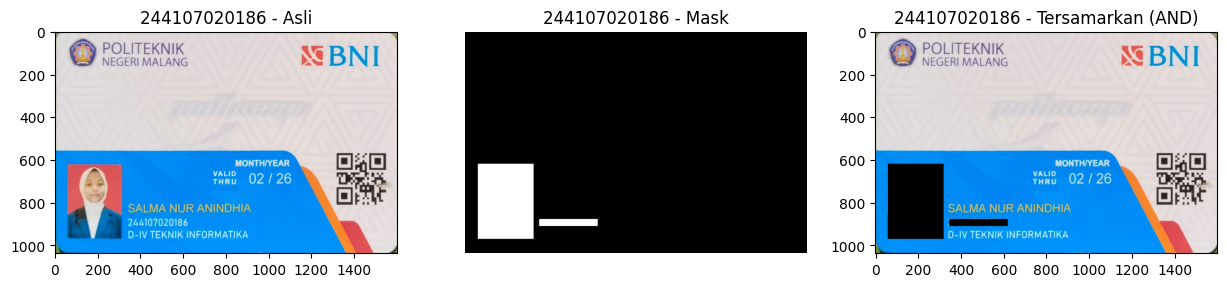

Koordinat mask wajah : (50,40)-(180,170)
Koordinat mask NIM   : (200,300)-(450,340)


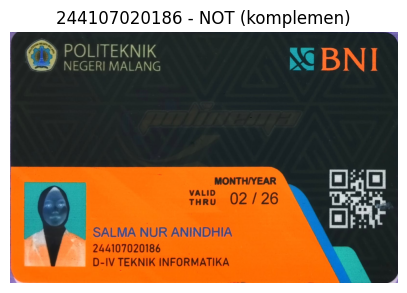

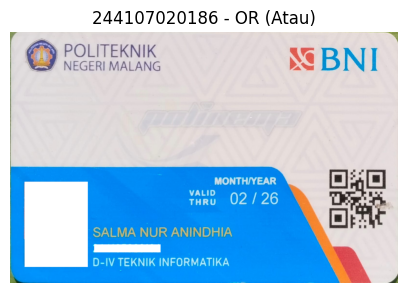

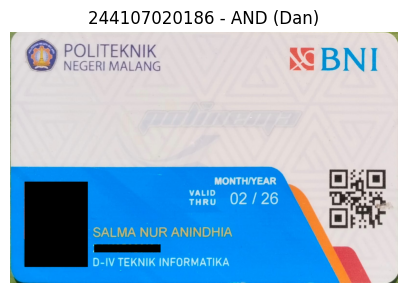

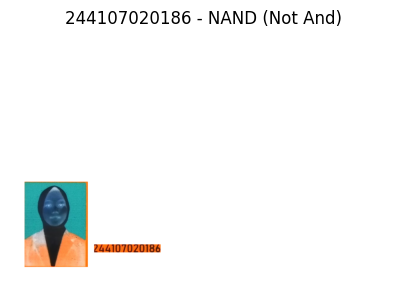

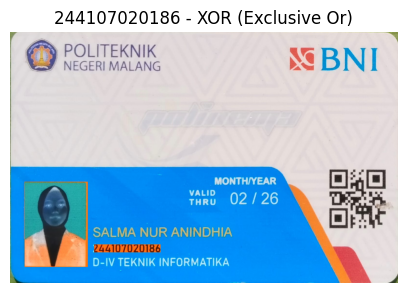

In [42]:
ktm1d = cv.imread('/content/drive/MyDrive/MATKUL BU HANI/KTM/KTM1d.jpeg')
h, w = ktm1d.shape[:2]
mask = np.zeros((h, w), dtype=np.uint8)

cv.rectangle(mask, (60, 620), (320, 970), 255, -1)
cv.rectangle(mask, (347, 910), (620, 878), 255, -1)

mask_inv = cv.bitwise_not(mask)
hasil_masked = cv.bitwise_and(ktm1d, ktm1d, mask=mask_inv)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(imshow_bgr(ktm1d)); ax[0].set_title(NIM + ' - Asli'); ax[0].axis('on')
ax[1].imshow(mask, cmap='gray'); ax[1].set_title(NIM + ' - Mask'); ax[1].axis('off')
ax[2].imshow(imshow_bgr(hasil_masked)); ax[2].set_title(NIM + ' - Tersamarkan (AND)'); ax[2].axis('on')
plt.show()
print('Koordinat mask wajah :', '(50,40)-(180,170)')
print('Koordinat mask NIM   :', '(200,300)-(450,340)')

mask_bgr = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)
operator_lain = {
    'NOT (komplemen)'   : cv.bitwise_not(ktm1d),
    'OR (Atau)'         : cv.bitwise_or(ktm1d, mask_bgr),
    'AND (Dan)'         : hasil_masked,
    'NAND (Not And)'    : cv.bitwise_not(cv.bitwise_and(ktm1d, mask_bgr)),
    'XOR (Exclusive Or)': cv.bitwise_xor(ktm1d, mask_bgr),
}
for nama, hasil in operator_lain.items():
    plt.figure(figsize=(5,5)); plt.imshow(imshow_bgr(hasil)); plt.title(NIM + ' - ' + nama); plt.axis('off'); plt.show()

Operasi bitwise memberi efek yg beda pada gambar, AND ini menyamarkan nim dan foto jdi hitam, NOT membalik warna jdi negatif, lalu OR membikin area mask jdi putih, kebalikan dri NAND yg membuat area selain mask putih, lalu XOR membalik warna dibagian mask saja, sisanya sama seperti asli.

In [48]:
def contrast_ab(img, alpha=1.0, beta=0):
    return cv.convertScaleAbs(img, alpha=alpha, beta=beta)

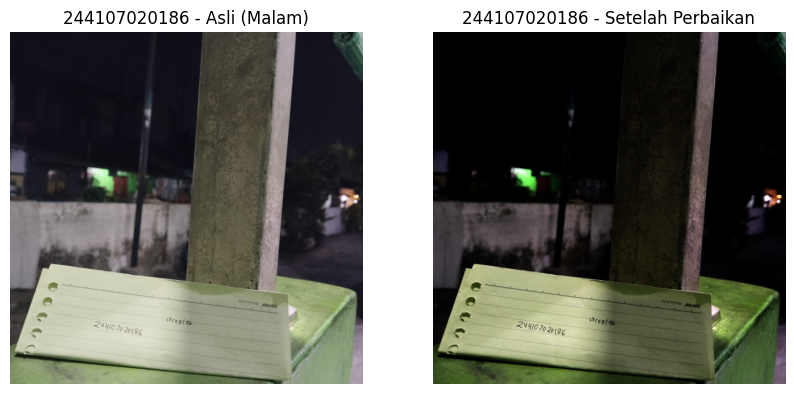

In [49]:
night = cv.imread('/content/drive/MyDrive/MATKUL BU HANI/KTM/NIGHT1.jpeg')

hasil_gamma = gamma_correction(night, 0.4)
hasil_final = contrast_ab(hasil_gamma, 1.2, 0)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(imshow_bgr(night)); ax[0].set_title(NIM + ' - Asli (Malam)'); ax[0].axis('off')
ax[1].imshow(imshow_bgr(hasil_final)); ax[1].set_title(NIM + ' - Setelah Perbaikan'); ax[1].axis('off')
plt.show()

1. Metode yg dipilih yaitu gamma correction + contrast adjusment
2. Kenapa memilih gamma, karna dia dipakai untuk mencerahkan bagian gelap, tanpa membikin area yg terang terlalu terang
3. Parameter terbaik gamma 0,4